# Molecular Dynamics Simulations

In [1]:
import hoomd
import matplotlib
import numpy

%matplotlib inline
matplotlib.style.use("ggplot")
import matplotlib_inline

matplotlib_inline.backend_inline.set_matplotlib_formats("svg")

In [2]:
integrator = hoomd.md.Integrator(dt=0.005)

In [3]:
integrator.dt

0.005

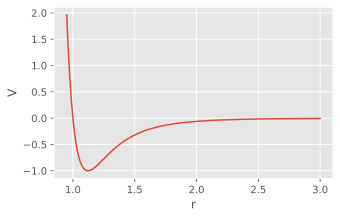

In [4]:
sigma = 1
epsilon = 1
r = numpy.linspace(0.95, 3, 500)
V_lj = 4 * epsilon * ((sigma / r) ** 12 - (sigma / r) ** 6)

fig = matplotlib.figure.Figure(figsize=(5, 3.09))
ax = fig.add_subplot()
ax.plot(r, V_lj)
ax.set_xlabel("r")
ax.set_ylabel("V")
fig

In [5]:
cell = hoomd.md.nlist.Cell(buffer=0.4)

In [6]:
lj = hoomd.md.pair.LJ(nlist=cell)

In [7]:
lj.params[("A", "A")] = dict(epsilon=1, sigma=1)
lj.r_cut[("A", "A")] = 2.5

In [8]:
integrator.forces.append(lj)

In [9]:
nvt = hoomd.md.methods.ConstantVolume(
    filter=hoomd.filter.All(), thermostat=hoomd.md.methods.thermostats.Bussi(kT=1.5)
)

In [10]:
integrator.methods.append(nvt)

## Initializing A Random System

In [11]:
import itertools
import math

import gsd.hoomd
import hoomd
import numpy

In [12]:
m = 4
N_particles = 4 * m**3

In [13]:
spacing = 1.3
K = math.ceil(N_particles ** (1 / 3))
L = K * spacing
x = numpy.linspace(-L / 2, L / 2, K, endpoint=False)
position = list(itertools.product(x, repeat=3))

frame = gsd.hoomd.Frame()
frame.particles.N = N_particles
frame.particles.position = position[0:N_particles]
frame.particles.typeid = [0] * N_particles
frame.configuration.box = [L, L, L, 0, 0, 0]

In [14]:
frame.particles.types = ["A"]

In [15]:
import os

fn = os.path.join(os.getcwd(), "lattice.gsd")
![ -e "$fn" ] && rm "$fn"
fn = os.path.join(os.getcwd(), "random.gsd")
![ -e "$fn" ] && rm "$fn"





import warnings

import fresnel
import IPython
import packaging.version

device = fresnel.Device()
tracer = fresnel.tracer.Path(device=device, w=300, h=300)

FRESNEL_MIN_VERSION = packaging.version.parse("0.13.0")
FRESNEL_MAX_VERSION = packaging.version.parse("0.14.0")


def render(snapshot):
    if (
        "version" not in dir(fresnel)
        or packaging.version.parse(fresnel.version.version) < FRESNEL_MIN_VERSION
        or packaging.version.parse(fresnel.version.version) >= FRESNEL_MAX_VERSION
    ):
        warnings.warn(
            f"Unsupported fresnel version {fresnel.version.version} - expect errors."
        )
    L = snapshot.configuration.box[0]
    scene = fresnel.Scene(device)
    geometry = fresnel.geometry.Sphere(
        scene, N=len(snapshot.particles.position), radius=0.5
    )
    geometry.material = fresnel.material.Material(
        color=fresnel.color.linear([252 / 255, 209 / 255, 1 / 255]), roughness=0.5
    )
    geometry.position[:] = snapshot.particles.position[:]
    geometry.outline_width = 0.04
    fresnel.geometry.Box(scene, [L, L, L, 0, 0, 0], box_radius=0.02)

    scene.lights = [
        fresnel.light.Light(direction=(0, 0, 1), color=(0.8, 0.8, 0.8), theta=math.pi),
        fresnel.light.Light(
            direction=(1, 1, 1), color=(1.1, 1.1, 1.1), theta=math.pi / 3
        ),
    ]
    scene.camera = fresnel.camera.Orthographic(
        position=(L * 2, L, L * 2), look_at=(0, 0, 0), up=(0, 1, 0), height=L * 1.4 + 1
    )
    scene.background_alpha = 1
    scene.background_color = (1, 1, 1)
    samples = 2000
    if "CI" in os.environ:
        samples = 100
    return IPython.display.Image(tracer.sample(scene, samples=samples)._repr_png_())

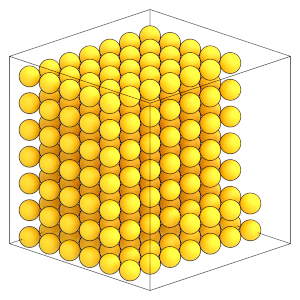

In [16]:
render(frame)

In [21]:
with gsd.hoomd.open(name="lattice.gsd", mode="w") as f:
    f.append(frame)

In [22]:
cpu = hoomd.device.CPU()
simulation = hoomd.Simulation(device=cpu, seed=1)
simulation.create_state_from_gsd(filename="lattice.gsd")

In [23]:
integrator = hoomd.md.Integrator(dt=0.005)
cell = hoomd.md.nlist.Cell(buffer=0.4)
lj = hoomd.md.pair.LJ(nlist=cell)
lj.params[("A", "A")] = dict(epsilon=1, sigma=1)
lj.r_cut[("A", "A")] = 2.5
integrator.forces.append(lj)
nvt = hoomd.md.methods.ConstantVolume(
    filter=hoomd.filter.All(), thermostat=hoomd.md.methods.thermostats.Bussi(kT=1.5)
)
integrator.methods.append(nvt)

In [24]:
simulation.operations.integrator = integrator

In [25]:
snapshot = simulation.state.get_snapshot()
snapshot.particles.velocity[0:5]

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [26]:
simulation.state.thermalize_particle_momenta(filter=hoomd.filter.All(), kT=1.5)

In [27]:
thermodynamic_properties = hoomd.md.compute.ThermodynamicQuantities(
    filter=hoomd.filter.All()
)

In [28]:
simulation.operations.computes.append(thermodynamic_properties)
simulation.run(0)

In [29]:
thermodynamic_properties.degrees_of_freedom

765.0

In [30]:
1 / 2 * 1.5 * thermodynamic_properties.degrees_of_freedom

573.75

In [31]:
thermodynamic_properties.kinetic_energy

622.0400392791

In [32]:
thermodynamic_properties.kinetic_temperature

1.6262484687035295

In [33]:
simulation.run(10000)

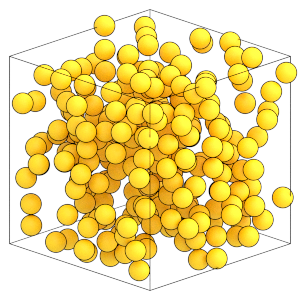

In [34]:
render(simulation.state.get_snapshot())

In [35]:
thermodynamic_properties.kinetic_energy

568.7459956734876

In [37]:
hoomd.write.GSD.write(state=simulation.state, filename="random.gsd", mode="wb")

## Compressing The System

In [38]:
import math

import hoomd
import matplotlib

%matplotlib inline
matplotlib.style.use("ggplot")
import matplotlib_inline

matplotlib_inline.backend_inline.set_matplotlib_formats("svg")

In [39]:
cpu = hoomd.device.CPU()
simulation = hoomd.Simulation(device=cpu, seed=1)
simulation.create_state_from_gsd(filename="random.gsd")

In [40]:
integrator = hoomd.md.Integrator(dt=0.005)
cell = hoomd.md.nlist.Cell(buffer=0.4)
lj = hoomd.md.pair.LJ(nlist=cell)
lj.params[("A", "A")] = dict(epsilon=1, sigma=1)
lj.r_cut[("A", "A")] = 2.5
integrator.forces.append(lj)
nvt = hoomd.md.methods.ConstantVolume(
    filter=hoomd.filter.All(), thermostat=hoomd.md.methods.thermostats.Bussi(kT=1.5)
)
integrator.methods.append(nvt)
simulation.operations.integrator = integrator

In [41]:
ramp = hoomd.variant.Ramp(A=0, B=1, t_start=simulation.timestep, t_ramp=20_000)

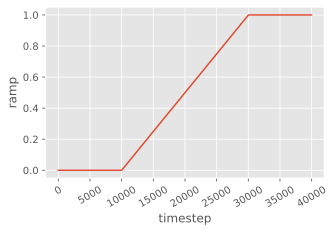

In [42]:
steps = range(0, 40000, 20)
y = [ramp(step) for step in steps]

fig = matplotlib.figure.Figure(figsize=(5, 3.09))
ax = fig.add_subplot()
ax.plot(steps, y)
ax.set_xlabel("timestep")
ax.set_ylabel("ramp")
ax.tick_params("x", labelrotation=30)
fig

In [43]:
rho = simulation.state.N_particles / simulation.state.box.volume
rho

0.3397157902913389

In [44]:
final_rho = 1.2
final_volume = simulation.state.N_particles / final_rho

In [45]:
inverse_volume_ramp = hoomd.variant.box.InverseVolumeRamp(
    initial_box=simulation.state.box,
    final_volume=final_volume,
    t_start=simulation.timestep,
    t_ramp=20_000,
)

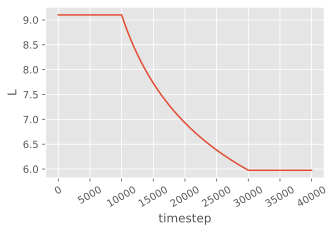

In [46]:
steps = range(0, 40000, 20)
y = [inverse_volume_ramp(step)[0] for step in steps]

fig = matplotlib.figure.Figure(figsize=(5, 3.09))
ax = fig.add_subplot()
ax.plot(steps, y)
ax.set_xlabel("timestep")
ax.set_ylabel("L")
ax.tick_params("x", labelrotation=30)
fig

In [47]:
box_resize = hoomd.update.BoxResize(
    trigger=hoomd.trigger.Periodic(10),
    box=inverse_volume_ramp,
)
simulation.operations.updaters.append(box_resize)

In [48]:
simulation.run(20001)

In [49]:
simulation.state.N_particles / simulation.state.box.volume

1.1999999999999995

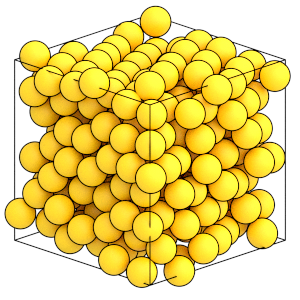

In [50]:
render(simulation.state.get_snapshot())

In [51]:
simulation.operations.updaters.remove(box_resize)

In [52]:
simulation.run(5e4)

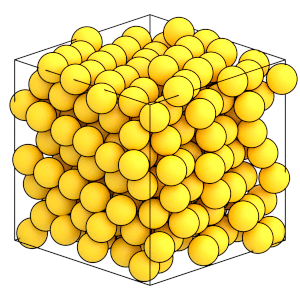

In [53]:
render(simulation.state.get_snapshot())